# Variance Gamma: a pure-jump model via a random clock

Every model so far has had a Brownian diffusion at its core: BSM is pure
diffusion, Heston is diffusion with stochastic variance, Merton/Kou/Bates are
diffusion plus jumps. Variance Gamma (Madan, Carr, Chang 1998) throws the
diffusion away entirely. It is a **pure-jump** process, no continuous Brownian
part at all.

Yet its paths look almost continuous. VG is an **infinite-activity** jump
process: infinitely many jumps in any interval, but almost all infinitesimally
small, with only a few large. Contrast the finite-activity jump-diffusions
(Merton, Kou), which have a finite number of meaningful jumps per year. VG is
"a dense spray of mostly-tiny jumps, a few large," and it captures skew and fat
tails through the distribution of jump sizes rather than a diffusion-plus-jump
split.

VG is the contrast piece in the cross-model benchmark: three parameters, no
diffusion, versus Bates's eight with both diffusion and jumps. The sharp
question is whether a parsimonious pure-jump model fits the SPX smile
competitively with the rich Bates model.

## 1. Subordination: Brownian motion under a random clock

VG is built by running a drifting Brownian motion on a **random time clock**.
Evaluate the Brownian motion not at calendar time $t$ but at a random, increasing
amount of *business time* $\Gamma_t$:

$$X_t = \theta\,\Gamma_t + \sigma\,W_{\Gamma_t}$$

where $\Gamma_t$ is a **Gamma process** (the random clock) and $W$ is a standard
Brownian motion.

The direction matters and is easy to get backwards. Calendar time $t$ is *not*
random, it is the ordinary wall clock, the deterministic input. What is random is
the *business time* $\Gamma_t$, the amount of market activity accumulated by
calendar time $t$. At each fixed $t$, $\Gamma_t$ is Gamma-distributed with mean
$t$ and variance $\nu t$: business time tracks calendar time on average but
wobbles around it. As $t$ advances, $\Gamma_t$ advances by random increments,
sometimes racing ahead (a chaotic news period), sometimes crawling (a quiet one).

**Why "subordination".** When one process $W$ is evaluated at a random time given
by an increasing process $\Gamma$, the process $\Gamma$ is the *subordinator* and
$W_{\Gamma_t}$ is *subordinated* to it (Bochner, 1940s). The word names a
hierarchy: the clock $\Gamma$ governs the time at which $W$ is observed, so $W$ is
*subordinate to* the clock, it does not run on its own time, it runs on whatever
time the clock dictates. The clock must be non-decreasing (time only moves
forward); the Gamma process qualifies, being increasing with independent
Gamma-distributed increments.

The economic story: markets do not experience time uniformly. Some periods pack
in lots of information and trading (fast business time), others are quiet (slow).
Over one calendar hour, sometimes ten "business hours" of activity happen,
sometimes ten minutes' worth. A return is a Brownian increment over the *business*
time elapsed, so a chaotic hour produces a big move and a dead hour a tiny one.
The random clock turns uniform-variance Brownian increments into the fat-tailed,
variable-magnitude returns markets actually show.

## 2. The three parameters

- $\sigma$: volatility of the underlying Brownian motion. Overall scale.
- $\nu$: variance rate of the Gamma clock. Controls **kurtosis** (fat tails).
  $\nu \to 0$ makes the clock deterministic (business time = calendar time) and
  recovers pure Brownian motion; larger $\nu$ means a more erratic clock and
  fatter tails.
- $\theta$: drift of the Brownian motion in business time. Controls **skew**.
  $\theta < 0$ (down-drift) gives the left-skew of equity returns; $\theta = 0$
  gives a symmetric distribution.

A clean decomposition: $\sigma$ scales, $\nu$ fattens, $\theta$ tilts.

## 3. The distribution as a mixture of Gaussians

Conditional on the clock taking a specific value $\Gamma_t = g$, the return is
just Brownian motion observed at time $g$:

$$X_t \mid (\Gamma_t = g) \;\sim\; \mathcal{N}(\theta g,\ \sigma^2 g)$$

So each possible clock value gives a *different* Gaussian: a quiet-clock draw
(small $g$) is narrow and near zero; a busy-clock draw (large $g$) is wide *and*
more shifted (the drift $\theta$ accumulates over more business time). The actual
return distribution is the probability-weighted blend of all of them:

$$f_{X_t}(x) = \int_0^\infty \underbrace{f_{\mathcal{N}(\theta g,\ \sigma^2 g)}(x)}_{\text{conditional Gaussian}} \cdot \underbrace{f_\Gamma(g)}_{\text{clock density}}\ dg$$

a **continuous mixture of Gaussians**, one per clock value, weighted by the Gamma
density. Mechanically (and this is how we simulate it): draw a clock value $g$
from the Gamma, draw a return from $\mathcal{N}(\theta g, \sigma^2 g)$, repeat.
The pooled histogram is fatter-tailed than any single Gaussian, because the
wide-clock draws over-populate the tails. **That variance-mixing is where VG's
excess kurtosis comes from**, and the down-drift making wide draws also more
negative is where the skew comes from.

## 4. The characteristic function

Subordination pays off: compute the char func by conditioning on the clock, then
averaging. Conditional on $\Gamma_t = g$, the char func is the Gaussian's,
$\exp(g\,[iu\theta - \tfrac12\sigma^2 u^2])$, of the form $\exp(g \cdot s)$. Then
average over the Gamma-distributed $g$:

$$\phi(u) = \mathbb{E}_g\big[e^{g\,s}\big], \qquad s = iu\theta - \tfrac12\sigma^2 u^2.$$

But $\mathbb{E}_g[e^{gs}]$ is the **moment generating function of the Gamma
distribution**, which is a *power law*: $(1 - \nu s)^{-t/\nu}$. Hence

$$\phi_{VG}(u) = \left(1 - iu\theta\nu + \tfrac12\sigma^2\nu u^2\right)^{-t/\nu}.$$

The power-law shape comes directly from the Gamma clock's MGF being a power law.
This is the deep tidy fact: a model's char func inherits the functional form of
the MGF of its driving randomness. The jump-diffusions have
exponential-of-exponential char funcs because their randomness is Poisson; VG has
a power-law char func because its randomness is a Gamma clock. It is arguably the
simplest char func of all the models here, a nice payoff for the conceptual
depth.

For the log-*price*, prepend the drift and a martingale correction:

$$\phi_{\ln S_T}(u) = e^{iu(\ln S_0 + (r - q + \omega)t)}\,\phi_{VG}(u),
\qquad \omega = \frac{1}{\nu}\log\!\left(1 - \theta\nu - \tfrac12\sigma^2\nu\right).$$

$\omega$ is the convexity correction (analogue of the jump compensator
$-\lambda\kappa_J$) that forces $\mathbb{E}[S_T] = S_0 e^{(r-q)t}$. It hides a
**parameter constraint**: the log's argument $1 - \theta\nu - \tfrac12\sigma^2\nu$
must be positive, or $\omega$ diverges. This bounds $\theta, \nu, \sigma$
together, the VG analogue of Kou's $\eta_1 > 1$ ("the process has finite mean").

## 5. Where VG sits, and what the benchmark should show

VG captures skew and kurtosis with three parameters and no diffusion, against
Bates's eight. It is known to fit a *single* maturity's smile well but to
struggle with the *term structure*: with no stochastic volatility, its skew and
kurtosis decay with maturity in a fixed way (roughly, skew $\sim \theta$ and
kurtosis $\sim \nu/t$, both shrinking as $t$ grows) that the market does not
follow.

So the expected benchmark finding is the mirror image of Heston. Heston had a
term structure but too little short-dated skew; VG has plenty of single-slice
skew/kurtosis but the wrong term structure. Bates, with both stochastic vol and
jumps, should be the one that gets both. That contrast, parsimonious-but-rigid VG
versus rich-but-heavy Bates, is exactly why VG earns its place in the benchmark.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from models.vg import vg_char_func, vg_cumulants, vg_simulate_terminal
from pricing.fourier import vg_cos_price
from models.bsm import bsm_price   # for the nu -> 0 (Brownian) limit check

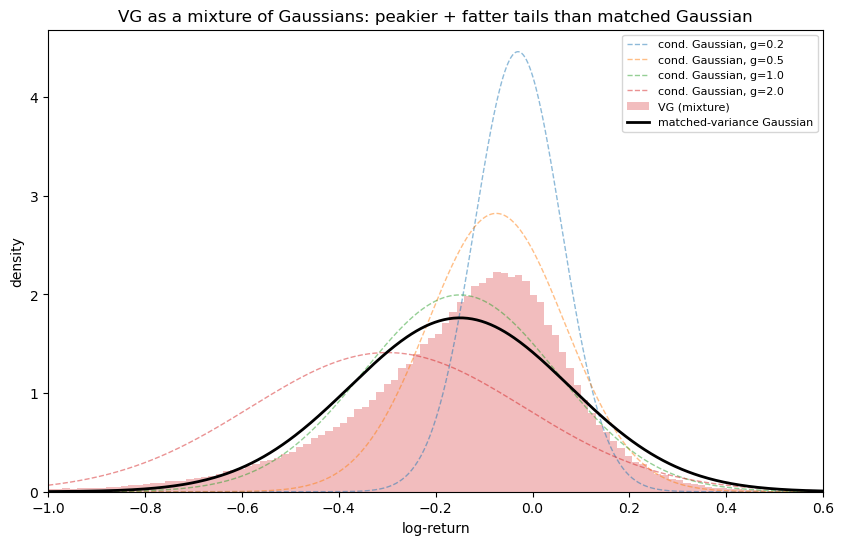

In [3]:
# DEMO 1: kurtosis from variance-mixing (the subordination "aha")
sigma, nu, theta, T = 0.2, 0.5, -0.15, 1.0
rng = np.random.default_rng(0)

# draw clock values, show a few conditional Gaussians
g_samples = rng.gamma(shape=T/nu, scale=nu, size=200_000)
x = np.linspace(-1.0, 0.6, 500)

from scipy.stats import norm
fig, ax = plt.subplots(figsize=(10, 6))

# a few conditional Gaussians N(theta*g, sigma^2*g), thin, for illustrative g values
for g in [0.2, 0.5, 1.0, 2.0]:
    cond = norm.pdf(x, loc=theta*g, scale=sigma*np.sqrt(g))
    ax.plot(x, cond, lw=1, alpha=0.5, ls="--", label=f"cond. Gaussian, g={g}")

# the actual VG return distribution: draw clock, then Gaussian, histogram
vg_returns = theta*g_samples + sigma*np.sqrt(g_samples)*rng.standard_normal(len(g_samples))
ax.hist(vg_returns, bins=200, density=True, alpha=0.3, color="tab:red", label="VG (mixture)")

# matched-variance single Gaussian for contrast
var_vg = (sigma**2 + nu*theta**2)*T
ax.plot(x, norm.pdf(x, loc=theta*T, scale=np.sqrt(var_vg)),
        lw=2, color="black", label="matched-variance Gaussian")

ax.set_xlim(-1.0, 0.6); ax.set_xlabel("log-return"); ax.set_ylabel("density")
ax.set_title("VG as a mixture of Gaussians: peakier + fatter tails than matched Gaussian")
ax.legend(fontsize=8)
plt.show()

### Result: kurtosis and skew emerge from variance-mixing

The dashed curves are conditional Gaussians $\mathcal{N}(\theta g, \sigma^2 g)$,
one per business-clock value $g$. They differ sharply: a quiet clock ($g=0.2$,
blue) gives a tall narrow Gaussian peaked near zero; a busy clock ($g=2.0$, red)
gives a short wide one, spread out and shifted left (the down-drift $\theta$
accumulates over more business time). The VG return distribution (red histogram)
is the probability-weighted blend of all such conditional Gaussians.

The comparison against the matched-variance Gaussian (black) is the point. Both
have identical variance by construction, yet their shapes differ:

- **Peakier center.** The VG mode (~2.2) sits well above the Gaussian's (~1.8).
  The pile-up of narrow, quiet-clock Gaussians concentrates mass at the center.
- **Fatter tails.** The VG sits above the Gaussian in the far left tail; the
  wide, busy-clock Gaussians push mass out past where a single Gaussian of the
  same variance would place it.
- **Left lean (skew).** With $\theta < 0$, the wide (busy-clock) draws are also
  the more negative ones, so the excess mass in the tail is asymmetric, heavier
  on the downside.

Peakier center plus fatter tails at fixed variance *is* excess kurtosis, and here
it is built mechanically: mixing narrow and wide Gaussians of the same average
variance produces more peak and more tail than any single Gaussian. The down-drift
tilting the wide draws produces the skew. Both the fat tails and the skew, the two
features a Gaussian cannot capture, come directly from the random clock. This is
what "subordination generates non-Gaussian returns" means concretely.

(At $\nu = 0.5$ the effect is moderate and shows more in the peak than the tails.
Larger $\nu$, a more erratic clock, makes the tail excess starker; smaller $\nu$
collapses toward the Gaussian, since the clock becomes near-deterministic.)

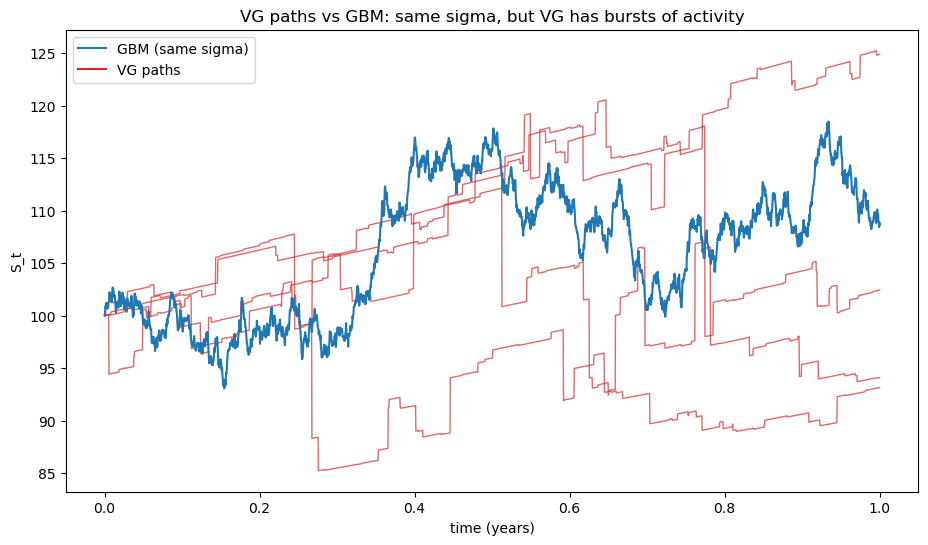

In [12]:
# DEMO 2: Variance Gamma paths
def vg_path(S0, r, q, T, sigma, nu, theta, n_steps, seed=None):
    """Full VG price path via incremental subordination."""
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    omega = (1.0/nu) * np.log(1.0 - theta*nu - 0.5*sigma**2*nu)

    dGamma = rng.gamma(shape=dt/nu, scale=nu, size=n_steps)      # business-time increments
    Z = rng.standard_normal(n_steps)
    dX = theta*dGamma + sigma*np.sqrt(dGamma)*Z                  # VG log-return increments
    drift = (r - q + omega) * dt
    log_S = np.log(S0) + np.cumsum(drift + dX)
    log_S = np.concatenate([[np.log(S0)], log_S])
    return np.exp(log_S)

def bm_path(S0, r, q, T, sigma, n_steps, seed=None):
    """Plain GBM path, same sigma, for contrast."""
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.standard_normal(n_steps)
    dlog = (r - q - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_S = np.log(S0) + np.cumsum(np.concatenate([[0], dlog]))
    return np.exp(log_S)

S0, r, q, T, sigma, nu, theta = 100.0, 0.03, 0.0, 1.0, 0.2, 0.1, -0.15
n_steps = 2520
t = np.linspace(0, T, n_steps + 1)

fig, ax = plt.subplots(figsize=(11, 6))
for i in range(4):
    ax.plot(t, vg_path(S0, r, q, T, sigma, nu, theta, n_steps, seed=645*i),
            lw=1, color="tab:red", alpha=0.7)
ax.plot(t, bm_path(S0, r, q, T, sigma, n_steps, seed=9679),
        lw=1.5, color="tab:blue", label="GBM (same sigma)")
ax.plot([], [], color="tab:red", label="VG paths")
ax.set_xlabel("time (years)"); ax.set_ylabel("S_t")
ax.set_title("VG paths vs GBM: same sigma, but VG has bursts of activity")
ax.legend()
plt.show()

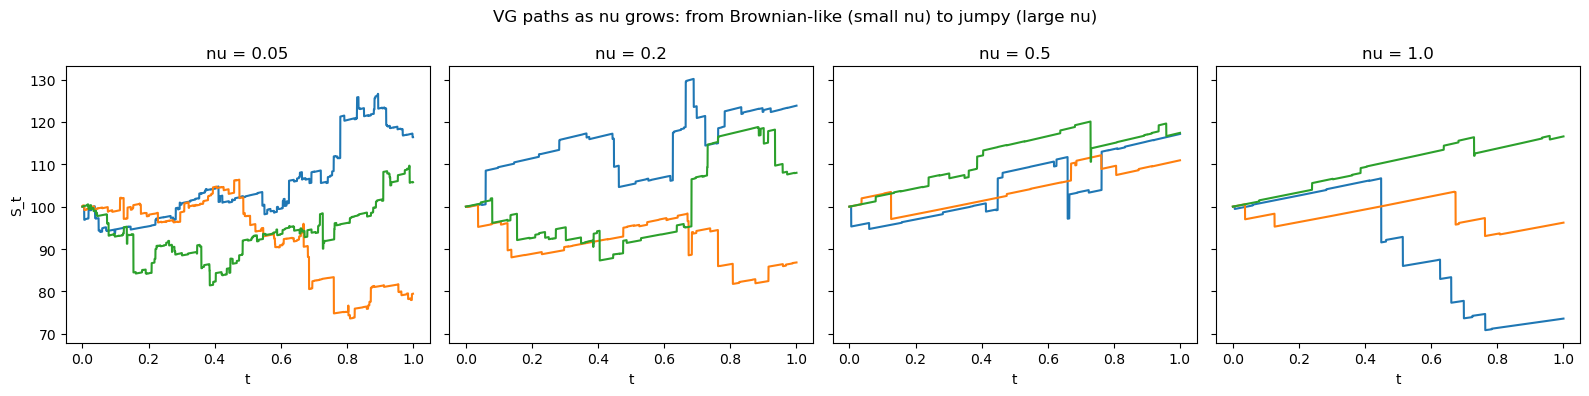

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, nu_val in zip(axes, [0.05, 0.2, 0.5, 1.0]):
    for i in range(3):
        ax.plot(t, vg_path(S0, r, q, T, sigma, nu_val, theta, n_steps, seed=i))
    ax.set_title(f"nu = {nu_val}")
    ax.set_xlabel("t")
axes[0].set_ylabel("S_t")
fig.suptitle("VG paths as nu grows: from Brownian-like (small nu) to jumpy (large nu)")
plt.tight_layout()
plt.show()

### VG paths: nu dials from Brownian-like to jumpy

The path plot contrasts VG (red) against GBM at the same sigma (blue). GBM is
uniform jitter, wiggling continuously at roughly constant amplitude. VG is
different in character: near-deterministic drift over quiet stretches, punctuated
by sharp lurches. That flat-then-lurch shape is the random clock at work, during
a quiet-clock stretch business time barely advances so the price tracks the drift
almost linearly, then a busy-clock step advances business time a lot and the price
lurches.

The key parameter is nu, the variance rate of the clock, and it controls where VG
sits on a spectrum:

- Small nu (near 0): the clock is nearly deterministic (business time approx
  calendar time), so VG approaches pure Brownian motion. Paths look GBM-like.
  This is the same limit the nu -> 0 validation gate confirmed numerically
  (VG price -> BSM price).
- Large nu (here 0.5): the clock is highly erratic, its increments extremely
  right-skewed (mostly near-zero, occasional large leaps), so the path is
  dominated by bursts. Paths look jump-like.

So nu is literally the knob between diffusion-like and jump-like behaviour, the
path-level view of what "nu controls kurtosis" means. At small nu the returns are
near-Gaussian (thin tails); at large nu the clustered bursts produce the fat tails
and excess kurtosis seen in the mixture-of-Gaussians demo.

A note on resolution and infinite activity. VG has infinitely many jumps in any
interval, almost all infinitesimal. At daily resolution those tiny jumps cannot be
resolved, so between the rare large clock-leaps the path looks like smooth drift
rather than diffuse jitter. Finer time steps fill in more of the small-jump
texture, but the burst character at moderate-to-large nu persists because it is a
property of the clock's heavy-tailed increments, not of the discretisation. This
is the visual signature of infinite activity: it looks diffuse when under-resolved
and jumpy where the clock leaps, and unlike a finite-activity jump model (Merton,
Bates) there are no isolated clean gaps, the "jumps" are a dense spray, not
discrete events.

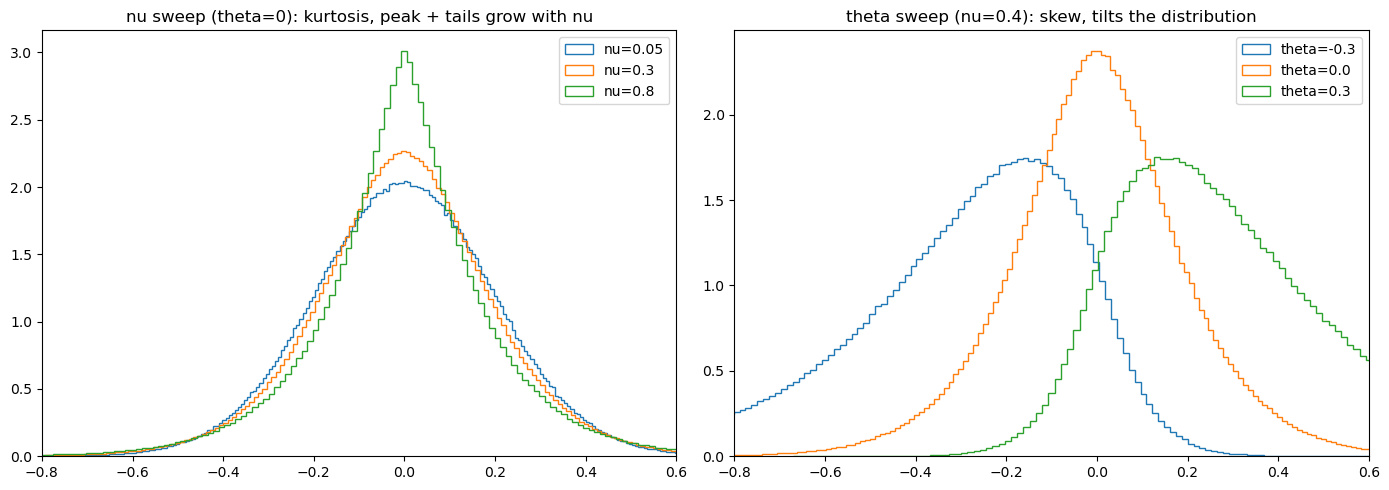

In [14]:
# Demo 3: parameter sweeps on the density
from scipy.stats import norm
x = np.linspace(-0.8, 0.6, 500)
T = 1.0

def vg_density_mc(sigma, nu, theta, T, n=2_000_000, seed=0):
    rng = np.random.default_rng(seed)
    g = rng.gamma(shape=T/nu, scale=nu, size=n)
    return theta*g + sigma*np.sqrt(g)*rng.standard_normal(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# nu sweep (kurtosis), theta fixed at 0 so we isolate kurtosis from skew
for nu_val in [0.05, 0.3, 0.8]:
    r_ = vg_density_mc(0.2, nu_val, 0.0, T)
    axes[0].hist(r_, bins=300, density=True, histtype="step", label=f"nu={nu_val}")
axes[0].set_title("nu sweep (theta=0): kurtosis, peak + tails grow with nu")
axes[0].set_xlim(-0.8, 0.6); axes[0].legend()

# theta sweep (skew), nu fixed
for th in [-0.3, 0.0, 0.3]:
    r_ = vg_density_mc(0.2, 0.4, th, T)
    axes[1].hist(r_, bins=300, density=True, histtype="step", label=f"theta={th}")
axes[1].set_title("theta sweep (nu=0.4): skew, tilts the distribution")
axes[1].set_xlim(-0.8, 0.6); axes[1].legend()
plt.tight_layout(); plt.show()

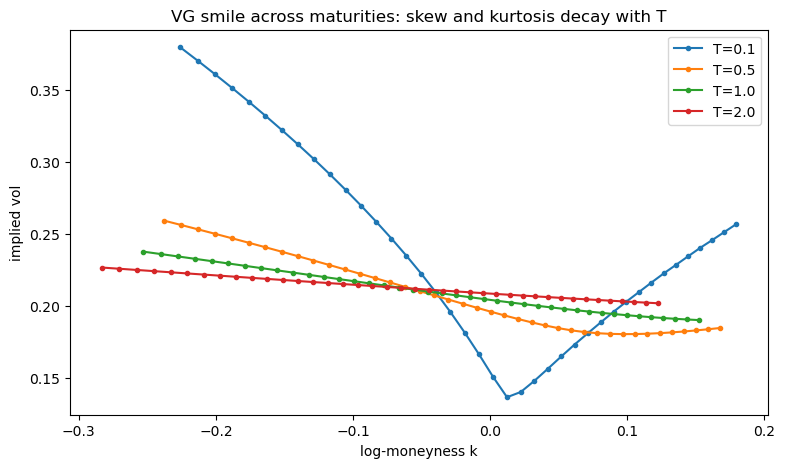

In [15]:
# Demo 4: the VG smile across maturities
from calibration.implied_vol import bsm_implied_vol
S0, r, q = 100.0, 0.03, 0.0
sigma, nu, theta = 0.2, 0.4, -0.15
strikes = np.linspace(80, 120, 40)

fig, ax = plt.subplots(figsize=(9, 5))
for T in [0.1, 0.5, 1.0, 2.0]:
    F = S0*np.exp((r-q)*T)
    k = np.log(strikes/F)
    px = np.array([vg_cos_price(S0, r, q, T, sigma, nu, theta, K, "call") for K in strikes])
    iv = [bsm_implied_vol(p, S0, K, T, r, "call", b=r-q) for p, K in zip(px, strikes)]
    ax.plot(k, iv, "o-", ms=3, label=f"T={T}")
ax.set_xlabel("log-moneyness k"); ax.set_ylabel("implied vol")
ax.set_title("VG smile across maturities: skew and kurtosis decay with T")
ax.legend()
plt.show()

### Parameter effects and the term-structure weakness

**Demo 3 (density sweeps):** the two panels isolate VG's parameters cleanly.
Sweeping nu with theta=0 shows pure kurtosis, the density gets peakier AND
fatter-tailed as nu grows (near-Gaussian at nu=0.05, sharply leptokurtic at
nu=0.8), with no skew. Sweeping theta at fixed nu shows pure skew, the
distribution tilts left for theta<0, right for theta>0, symmetric at 0, with no
change in peakedness. So nu fattens, theta tilts, an independent two-parameter
decomposition of the non-Gaussian shape. (The histogram jaggedness is Monte Carlo
sampling noise, not structure; the densities are smooth.)

**Demo 4 (smile across maturities):** the headline VG result. The short-dated
smile (T=0.1) is a deep, sharply-curved V, steep skew and pronounced wing
curvature, exactly the short-dated shape a pure diffusion cannot make. But the
smile flattens dramatically with maturity: by T=2.0 it is nearly a flat line,
almost no skew or curve left.

The decisive point is that this flattening rate is not a free parameter. VG's
skew and kurtosis decay with T in a fixed way set by the same (sigma, nu, theta)
that fix the short-dated shape (skew tied to theta, kurtosis decaying like nu/T).
So once the parameters are chosen to match a short-dated smile, the long-dated
smile is determined, and VG cannot independently control it. If the market's
long-dated smile retains more skew than VG's forced flattening allows (it
typically does), VG cannot fit both ends of the surface at once.

This is the mirror image of Heston. Heston has a rich term structure via
stochastic volatility but flattens too fast at the short end (it cannot make a
steep 29 DTE skew). VG has abundant short-dated skew and curvature but flattens
too fast into the long end, with no lever to slow the decay. Bates, with both
stochastic volatility (term structure) and jumps (short-dated tail), should fit
both ends where each of these single-mechanism models fails at one.

This plot is therefore the benchmark's thesis in advance: VG should fit any single
maturity slice well but fail to fit a full multi-maturity surface simultaneously,
the signature of a model rich in single-slice shape but rigid in term structure.